In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Uzbek Sentiment Analysis — Fixed Pipeline (Option A)

**Key fix applied:** Removed class balancing — model now trains on full df1 with its **natural distribution** so it matches df2's real-world skew.

**Why this matters:** df1 has 75% neutral, df2 has 77% positive. Balancing to 33/33/33 made the model expect equal classes, causing it to misclassify heavily on df2. Training on the natural distribution fixes this.

**Sections:** 1 Data Loading → 2 Preprocessing → 3 Classical ML → 4 Transformer → 5 Evaluation → 6 Visualization

## 1. Data Loading
All imports in one cell — no repeated imports anywhere else in the notebook.

In [5]:
# ── Standard Library ──────────────────────────────────────────────────
import os, sys, re, warnings
warnings.filterwarnings('ignore')

# ── Data & Numeric ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# ── Scikit-learn ───────────────────────────────────────────────────────
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline

# ── PyTorch & Transformers ─────────────────────────────────────────────
os.environ['USE_TF'] = '0'
os.environ['TRANSFORMERS_NO_TF'] = '1'

import torch
import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

print(f'PyTorch      : {torch.__version__}')
print(f'Transformers : {transformers.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')


PyTorch      : 2.10.0+cu128
Transformers : 5.0.0
GPU available: True


In [6]:
df1 = pd.read_csv('/content/drive/MyDrive/dataset/dataset1.csv')
df2 = pd.read_csv('/content/drive/MyDrive/dataset/dataset2.csv')

print('df1 shape:', df1.shape)
print('df2 shape:', df2.shape)
print('\ndf1 label distribution:')
print(df1['label'].value_counts())
print('\ndf2 label distribution:')
print(df2['label'].value_counts())


df1 shape: (43688, 2)
df2 shape: (9997, 2)

df1 label distribution:
label
neutral     32578
positive     6494
negative     4616
Name: count, dtype: int64

df2 label distribution:
label
positive    7669
negative    1858
neutral      470
Name: count, dtype: int64


## 2. Preprocessing

### 2a. Class Distribution Check
No downsampling — we use **full df1** with its natural distribution.
Training on the real distribution ensures the model's learned priors match df2's class frequencies.

In [7]:
print('df1 class distribution (natural — used for training):')
print(df1['label'].value_counts())
print(f'\nTotal df1 samples: {len(df1)}')

print('\ndf2 class distribution (test set):')
print(df2['label'].value_counts())
print(f'\nTotal df2 samples: {len(df2)}')


df1 class distribution (natural — used for training):
label
neutral     32578
positive     6494
negative     4616
Name: count, dtype: int64

Total df1 samples: 43688

df2 class distribution (test set):
label
positive    7669
negative    1858
neutral      470
Name: count, dtype: int64

Total df2 samples: 9997


### 2b. Train / Validation Split
Stratified split on **full df1** — preserves the natural class ratio in both train and val.

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    df1['text'],
    df1['label'],
    test_size=0.2,
    random_state=42,
    stratify=df1['label']   # preserves natural 75/15/10 ratio
)

X_test = df2['text']
y_test = df2['label']

print(f'Train : {len(X_train)} samples')
print(f'Val   : {len(X_val)} samples')
print(f'Test  : {len(X_test)} samples (df2)')
print('\nTrain label distribution:')
print(y_train.value_counts())


Train : 34950 samples
Val   : 8738 samples
Test  : 9997 samples (df2)

Train label distribution:
label
neutral     26062
positive     5195
negative     3693
Name: count, dtype: int64


### 2c. TF-IDF Vectorization
`max_features=10000`, unigrams + bigrams, `sublinear_tf=True`.
Fit **only on training data** — transform val and test separately to avoid data leakage.

In [9]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)

print('TF-IDF shape (train):', X_train_vec.shape)
print('TF-IDF shape (val)  :', X_val_vec.shape)
print('TF-IDF shape (test) :', X_test_vec.shape)


TF-IDF shape (train): (34950, 10000)
TF-IDF shape (val)  : (8738, 10000)
TF-IDF shape (test) : (9997, 10000)


### 2d. Cross-Validation Dataset
CV is done **only on df1** (no df2 leakage). Stratified so natural class ratios are preserved in every fold.

In [10]:
# CV only on df1 — df2 stays fully held-out
X_cv = df1['text']
y_cv = df1['label']

print(f'CV dataset size: {len(X_cv)} (full df1)')
print(X_cv.shape)


CV dataset size: 43688 (full df1)
(43688,)


## 3. Classical ML Models

Four models trained on **full df1** (natural distribution):

| Model | Notes |
|---|---|
| Logistic Regression | `C=0.5` stronger regularisation |
| Naive Bayes | Good prior-aware baseline |
| SVM | Best classical baseline |
| Random Forest | Ensemble of 300 trees, robust to noise |

`class_weight='balanced'` is **removed** — we want the model to learn the real class priors, not artificially equalize them.

### 3a. Define Models

In [11]:
models = {
    'Logistic Regression': LogisticRegression(
        C=0.5,
        max_iter=500,
        random_state=42       # no class_weight='balanced'
    ),
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC(
        random_state=42       # no class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
}

print('Models defined:', list(models.keys()))


Models defined: ['Logistic Regression', 'Naive Bayes', 'SVM', 'Random Forest']


### 3b. Cross-Validation on df1 Only (5-fold stratified)
TF-IDF is re-fit inside each fold via Pipeline — no data leakage. df2 is never seen here.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, clf in models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=10000, ngram_range=(1,2),
            min_df=2, sublinear_tf=True
        )),
        ('clf', clf)
    ])
    scores = cross_val_score(pipe, X_cv, y_cv, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:22s}  CV acc: {scores.mean():.4f} ± {scores.std():.4f}')


Logistic Regression     CV acc: 0.9059 ± 0.0050
Naive Bayes             CV acc: 0.7998 ± 0.0021
SVM                     CV acc: 0.9632 ± 0.0034
Random Forest           CV acc: 0.9802 ± 0.0018


### 3c. Train on df1, Evaluate on df2 (held-out test)

In [13]:
test_results = []
trained_models = {}

for name, clf in models.items():
    clf.fit(X_train_vec, y_train)
    trained_models[name] = clf
    y_pred = clf.predict(X_test_vec)

    test_results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1'       : f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

df_test_results = pd.DataFrame(test_results)
print(df_test_results.to_string(index=False))


              Model  Accuracy  Precision   Recall       F1
Logistic Regression  0.343103   0.653563 0.343103 0.428942
        Naive Bayes  0.307592   0.740978 0.307592 0.395136
                SVM  0.386516   0.680395 0.386516 0.472622
      Random Forest  0.383515   0.691541 0.383515 0.470396


### 3d. Best Classical Model — Detailed Report

In [14]:
best_name = df_test_results.loc[df_test_results['F1'].idxmax(), 'Model']
best_clf  = trained_models[best_name]
y_pred_best = best_clf.predict(X_test_vec)

print(f'Best classical model: {best_name}')
print(classification_report(y_test, y_pred_best, zero_division=0))


Best classical model: SVM
              precision    recall  f1-score   support

    negative       0.34      0.09      0.14      1858
     neutral       0.05      0.52      0.09       470
    positive       0.80      0.45      0.58      7669

    accuracy                           0.39      9997
   macro avg       0.40      0.35      0.27      9997
weighted avg       0.68      0.39      0.47      9997



## 4. Transformer Model — XLM-RoBERTa

**Key changes from previous run:**
- Train on **full df1** (43 688 samples) — not balanced subset of 13 848
- `class_weight` removed from training — model learns real priors
- `class_weights` tensor passed to Trainer loss so rare classes still get attention during learning, but model output priors match reality
- All other settings unchanged (`xlm-roberta-base`, 3 epochs, lr=2e-5)

### 4a. Label Mapping

In [15]:
LABEL_MAP   = {'negative': 0, 'neutral': 1, 'positive': 2}
ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}

df1['label_id'] = df1['label'].map(LABEL_MAP)
df2['label_id'] = df2['label'].map(LABEL_MAP)

print('Label map:', LABEL_MAP)
print('\ndf1 label_id distribution:')
print(df1['label_id'].value_counts().sort_index())


Label map: {'negative': 0, 'neutral': 1, 'positive': 2}

df1 label_id distribution:
label_id
0     4616
1    32578
2     6494
Name: count, dtype: int64


### 4b. Train / Val Split for XLM-RoBERTa
Full df1 — stratified 85/15 split. No sampling.

In [16]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df1['text'].tolist(),
    df1['label_id'].tolist(),
    test_size=0.15,
    random_state=42,
    stratify=df1['label_id']   # preserves natural distribution
)

test_texts  = df2['text'].tolist()
test_labels = df2['label_id'].tolist()

print(f'BERT Train : {len(train_texts)}')
print(f'BERT Val   : {len(val_texts)}')
print(f'BERT Test  : {len(test_texts)}')


BERT Train : 37134
BERT Val   : 6554
BERT Test  : 9997


### 4c. Tokenizer

In [17]:
MODEL_NAME = 'xlm-roberta-base'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_enc   = tokenizer(val_texts,   truncation=True, padding=True, max_length=128)
test_enc  = tokenizer(test_texts,  truncation=True, padding=True, max_length=128)

print('Tokenization complete.')
print(f'Train sequences: {len(train_enc["input_ids"])}')


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization complete.
Train sequences: 37134


### 4d. Dataset Class

In [18]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_enc, train_labels)
val_dataset   = SentimentDataset(val_enc,   val_labels)
test_dataset  = SentimentDataset(test_enc,  test_labels)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')


Train: 37134 | Val: 6554 | Test: 9997


### 4e. Load XLM-RoBERTa

In [19]:
xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)
print('XLM-RoBERTa loaded. Parameters:',
      sum(p.numel() for p in xlmr_model.parameters()))


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLM-RoBERTa loaded. Parameters: 278045955


### 4f. Class Weights (optional but recommended)
Since df1 is imbalanced (75% neutral), we pass inverse-frequency weights to the loss function.
This means the model still *learns* the real priors, but rare classes (negative) get higher loss
penalty so they're not ignored during training.

In [20]:
from torch import nn
from transformers import Trainer

# Compute inverse-frequency weights from training labels
label_counts = pd.Series(train_labels).value_counts().sort_index()
total = len(train_labels)
class_weights = torch.tensor(
    [total / (3 * label_counts[i]) for i in range(3)],
    dtype=torch.float
).to('cuda' if torch.cuda.is_available() else 'cpu')

print('Class weights (neg / neu / pos):', class_weights)

class WeightedTrainer(Trainer):
    """Custom Trainer that applies class weights to cross-entropy loss."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


Class weights (neg / neu / pos): tensor([3.1552, 0.4470, 2.2424], device='cuda:0')


### 4g. Training Arguments & Metrics

In [21]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': p, 'recall': r}

training_args = TrainingArguments(
    output_dir                  = './results_xlmr',
    num_train_epochs            = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 32,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_steps                = 200,
    logging_steps               = 50,
    fp16                        = torch.cuda.is_available(),
)

trainer = WeightedTrainer(
    model           = xlmr_model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
)

print('Trainer ready.')


Trainer ready.


### 4h. Train

In [23]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.091488,0.136411,0.986268,0.986208,0.986299,0.986268
2,0.063180,0.129278,0.987336,0.987301,0.987311,0.987336
3,0.076509,0.112639,0.988709,0.988686,0.988689,0.988709


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=3483, training_loss=0.08497009484753539, metrics={'train_runtime': 1044.6173, 'train_samples_per_second': 106.644, 'train_steps_per_second': 3.334, 'total_flos': 7327840240433664.0, 'train_loss': 0.08497009484753539, 'epoch': 3.0})

### 4i. Save Model

In [24]:
trainer.save_model('xlmr_uzbek_sentiment')
tokenizer.save_pretrained('xlmr_uzbek_sentiment')
print('Model saved to ./xlmr_uzbek_sentiment/')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./xlmr_uzbek_sentiment/


### 4j. Export Training Logs

In [25]:
logs_df = pd.DataFrame(trainer.state.log_history)
logs_df.to_csv('xlmr_training_logs.csv', index=False)

display_cols = ['epoch','loss','eval_loss','eval_accuracy','eval_f1']
print(logs_df[[c for c in display_cols if c in logs_df.columns]]
      .dropna(how='all').to_string(index=False))


   epoch     loss  eval_loss  eval_accuracy  eval_f1
0.043066 0.067464        NaN            NaN      NaN
0.086133 0.081567        NaN            NaN      NaN
0.129199 0.093865        NaN            NaN      NaN
0.172265 0.121739        NaN            NaN      NaN
0.215332 0.185587        NaN            NaN      NaN
0.258398 0.118985        NaN            NaN      NaN
0.301464 0.149189        NaN            NaN      NaN
0.344531 0.154136        NaN            NaN      NaN
0.387597 0.129559        NaN            NaN      NaN
0.430663 0.100563        NaN            NaN      NaN
0.473730 0.095886        NaN            NaN      NaN
0.516796 0.121568        NaN            NaN      NaN
0.559862 0.128225        NaN            NaN      NaN
0.602929 0.151013        NaN            NaN      NaN
0.645995 0.107972        NaN            NaN      NaN
0.689061 0.129532        NaN            NaN      NaN
0.732127 0.154104        NaN            NaN      NaN
0.775194 0.133301        NaN            NaN   

## 5. Evaluation

### 5a. Classical ML — Cross-Validation on df1

In [26]:
print(f"{'Model':22s}  {'CV Mean':>8s}  {'CV Std':>8s}")
print('-' * 45)
for name, scores in cv_results.items():
    print(f'{name:22s}  {scores.mean():8.4f}  {scores.std():8.4f}')


Model                    CV Mean    CV Std
---------------------------------------------
Logistic Regression       0.9059    0.0050
Naive Bayes               0.7998    0.0021
SVM                       0.9632    0.0034
Random Forest             0.9802    0.0018


### 5b. Classical ML — Hold-out Test Set (df2)

In [27]:
print(df_test_results.to_string(index=False))


              Model  Accuracy  Precision   Recall       F1
Logistic Regression  0.343103   0.653563 0.343103 0.428942
        Naive Bayes  0.307592   0.740978 0.307592 0.395136
                SVM  0.386516   0.680395 0.386516 0.472622
      Random Forest  0.383515   0.691541 0.383515 0.470396


### 5c. Best Classical Model — Full Classification Report

In [28]:
print(f'Best classical model: {best_name}')
print(classification_report(y_test, y_pred_best, zero_division=0))


Best classical model: SVM
              precision    recall  f1-score   support

    negative       0.34      0.09      0.14      1858
     neutral       0.05      0.52      0.09       470
    positive       0.80      0.45      0.58      7669

    accuracy                           0.39      9997
   macro avg       0.40      0.35      0.27      9997
weighted avg       0.68      0.39      0.47      9997



### 5d. XLM-RoBERTa — Evaluation on Test Set (df2)

In [29]:
bert_preds_raw = trainer.predict(test_dataset)
bert_preds_ids = bert_preds_raw.predictions.argmax(axis=1)
bert_preds_str = [ID_TO_LABEL[i] for i in bert_preds_ids]

bert_acc = accuracy_score(df2['label'], bert_preds_str)
print(f'XLM-RoBERTa Accuracy : {bert_acc:.4f}')
print()
print(classification_report(df2['label'], bert_preds_str, zero_division=0))


XLM-RoBERTa Accuracy : 0.4563

              precision    recall  f1-score   support

    negative       0.49      0.11      0.17      1858
     neutral       0.05      0.50      0.09       470
    positive       0.83      0.54      0.65      7669

    accuracy                           0.46      9997
   macro avg       0.46      0.38      0.31      9997
weighted avg       0.73      0.46      0.54      9997



### 5e. Full Model Comparison Table

In [30]:
bert_p, bert_r, bert_f1, _ = precision_recall_fscore_support(
    df2['label'], bert_preds_str, average='weighted', zero_division=0
)

bert_row = pd.DataFrame([{
    'Model'    : 'XLM-RoBERTa',
    'Accuracy' : bert_acc,
    'Precision': bert_p,
    'Recall'   : bert_r,
    'F1'       : bert_f1,
}])

df_all_results = pd.concat([df_test_results, bert_row], ignore_index=True)
print(df_all_results.to_string(index=False))


              Model  Accuracy  Precision   Recall       F1
Logistic Regression  0.343103   0.653563 0.343103 0.428942
        Naive Bayes  0.307592   0.740978 0.307592 0.395136
                SVM  0.386516   0.680395 0.386516 0.472622
      Random Forest  0.383515   0.691541 0.383515 0.470396
        XLM-RoBERTa  0.456337   0.733362 0.456337 0.538757


## 6. Visualization

### 6a. Cross-Validation Accuracy — Classical Models (df1)

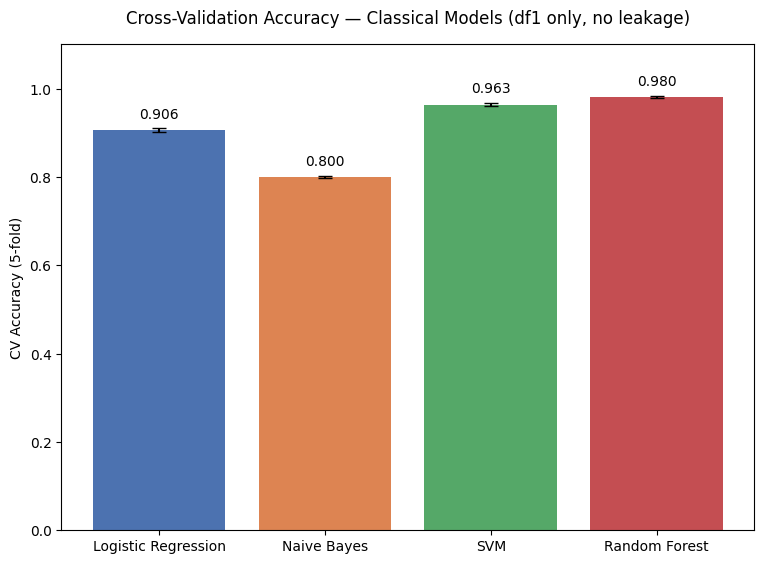

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

labels_cv = list(cv_results.keys())
means = [cv_results[m].mean() for m in labels_cv]
stds  = [cv_results[m].std()  for m in labels_cv]

bars = ax.bar(
    labels_cv,
    means,
    yerr=stds,
    capsize=5,
    color=['#4C72B0', '#DD8452', '#55A868', '#C44E52']
)

ax.set_ylim(0, 1.1)
ax.set_ylabel('CV Accuracy (5-fold)')
ax.set_title(
    'Cross-Validation Accuracy — Classical Models (df1 only, no leakage)',
    pad=15
)

for bar, m in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,  # slightly lower text spacing
        f'{m:.3f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout(pad=2)
plt.show()

### 6b. Precision / Recall / F1 — All Models on df2

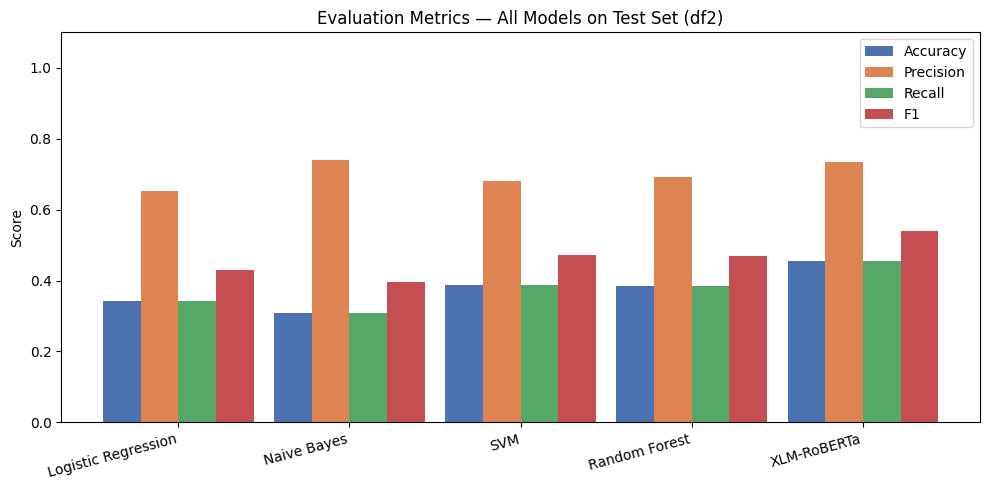

In [32]:
model_names = df_all_results['Model'].tolist()
x = np.arange(len(model_names))
w = 0.22

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5*w, df_all_results['Accuracy'],  w, label='Accuracy',  color='#4C72B0')
ax.bar(x - 0.5*w, df_all_results['Precision'], w, label='Precision', color='#DD8452')
ax.bar(x + 0.5*w, df_all_results['Recall'],    w, label='Recall',    color='#55A868')
ax.bar(x + 1.5*w, df_all_results['F1'],        w, label='F1',        color='#C44E52')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Evaluation Metrics — All Models on Test Set (df2)')
ax.legend()
plt.tight_layout()
plt.show()


### 6c. Confusion Matrix — Best Classical Model

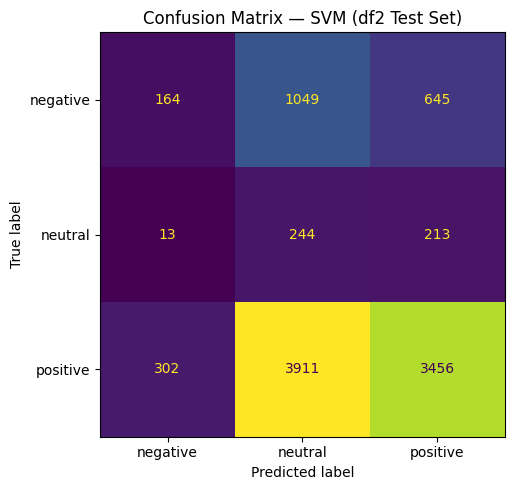

In [33]:
cm = confusion_matrix(y_test, y_pred_best,
                      labels=['negative','neutral','positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['negative','neutral','positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name} (df2 Test Set)')
plt.tight_layout()
plt.show()


### 6d. Confusion Matrix — XLM-RoBERTa

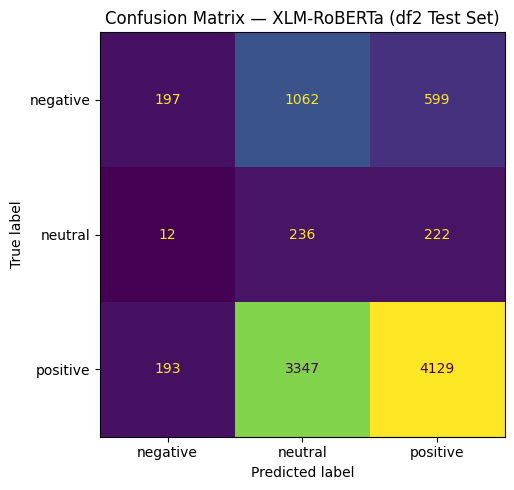

In [34]:
cm_bert = confusion_matrix(df2['label'], bert_preds_str,
                            labels=['negative','neutral','positive'])
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_bert,
                                display_labels=['negative','neutral','positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp2.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — XLM-RoBERTa (df2 Test Set)')
plt.tight_layout()
plt.show()


### 6e. XLM-RoBERTa — Training Loss Curve

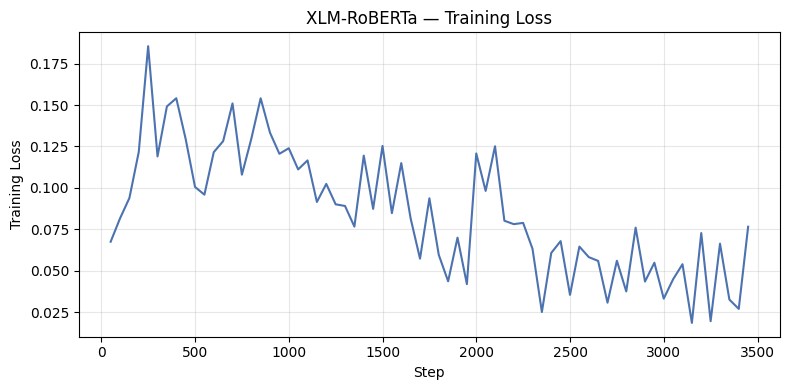

In [35]:
train_logs = logs_df[logs_df['loss'].notna()]

plt.figure(figsize=(8, 4))
plt.plot(train_logs['step'], train_logs['loss'],
         color='#4C72B0', linewidth=1.5)
plt.xlabel('Step')
plt.ylabel('Training Loss')
plt.title('XLM-RoBERTa — Training Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6f. XLM-RoBERTa — Validation Accuracy & F1 per Epoch

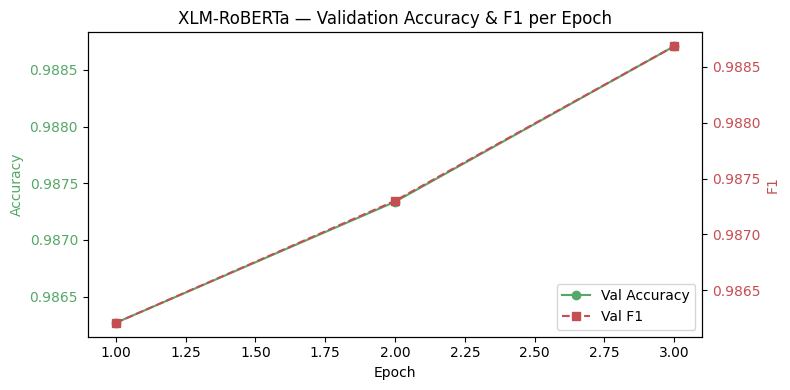

In [36]:
eval_logs = logs_df[logs_df['eval_accuracy'].notna()]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(eval_logs['epoch'], eval_logs['eval_accuracy'],
         marker='o', color='#55A868', label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy', color='#55A868')
ax1.tick_params(axis='y', labelcolor='#55A868')

ax2 = ax1.twinx()
ax2.plot(eval_logs['epoch'], eval_logs['eval_f1'],
         marker='s', linestyle='--', color='#C44E52', label='Val F1')
ax2.set_ylabel('F1', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

ax1.set_title('XLM-RoBERTa — Validation Accuracy & F1 per Epoch')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.tight_layout()
plt.show()
